In [1]:
import os
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import sklearn as sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import getpass
import act

### Setup for loading required data from arm

In [3]:
# Check for env variables, otherwise set your username and token here!
if "ARM_USERNAME" in os.environ:
    arm_username = os.getenv("ARM_USERNAME")
else:
    arm_username = input("Enter ARM username: ").strip()
if "ARM_TOKEN" in os.environ:
    arm_token = os.getenv("ARM_TOKEN")
else:
    arm_token = getpass.getpass("Enter ARM token (hidden): ").strip()

cf_datastream = 'bnfhsrlM1.a1'

# cloud free days (presumably)
start_date = '2026-05-13'
end_date = '2026-05-14'

bnf_hsrl = act.discovery.download_arm_data(arm_username, arm_token, cf_datastream, start_date, end_date)

Enter ARM username:  zmahatab
Enter ARM token (hidden):  ········


[DOWNLOADING] bnfhsrlM1.a1.20260513.000000.nc
[DOWNLOADING] bnfhsrlM1.a1.20260514.000000.nc

If you use these data to prepare a publication, please cite:

Holz, R., Garcia, J., Schuman, E., Bambha, R., Ermold, B., Eloranta, E., &
Garcia, J. High Spectral Resolution Lidar (HSRL), 2026-05-13 to 2026-05-14,
Bankhead National Forest, AL, USA; Long-term Mobile Facility (BNF), Bankhead
National Forest, AL, AMF3 (Main Site) (M1). Atmospheric Radiation Measurement
(ARM) User Facility. https://doi.org/10.5439/1462207



In [8]:
# Access Token: 64ff9d7b13f17708

In [4]:
bnf_hsrl_ds = act.io.read_arm_netcdf(bnf_hsrl)
bnf_hsrl_ds

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed


<xarray.Dataset> Size: 12GB
Dimensions:                                   (cal_time: 9, time: 5656,
                                               bound: 2, range: 667)
Coordinates:
  * time                                      (time) datetime64[ns] 45kB 2026...
  * range                                     (range) float32 3kB 0.0 ... 1.9...
  * cal_time                                  (cal_time) object 72B 2026-05-1...
Dimensions without coordinates: bound
Data variables: (12/111)
    base_time                                 (cal_time, time) object 407kB 2...
    time_offset                               (cal_time, time) object 407kB dask.array<chunksize=(5, 471), meta=np.ndarray>
    time_bounds                               (cal_time, time, bound) object 814kB dask.array<chunksize=(5, 1, 2), meta=np.ndarray>
    range_bounds                              (cal_time, time, range, bound) float32 272MB dask.array<chunksize=(5, 2828, 667, 2), meta=np.ndarray>
    cal_trigger                               (time, cal_time) float32 204kB dask.array<chunksize=(2828, 5), meta=np.ndarray>
    top_alt_sounding                          (time, cal_time) float32 204kB dask.array<chunksize=(2828, 5), meta=np.ndarray>
    ...                                        ...
    profile_num_molecular_photons_1064        (cal_time, time, range) float32 136MB dask.array<chunksize=(5, 2828, 667), meta=np.ndarray>
    profile_num_cross_polarized_photons       (cal_time, time, range) float32 136MB dask.array<chunksize=(5, 2828, 667), meta=np.ndarray>
    profile_num_cross_polarized_photons_1064  (cal_time, time, range) float32 136MB dask.array<chunksize=(5, 2828, 667), meta=np.ndarray>
    lat                                       (cal_time, time) float32 204kB ...
    lon                                       (cal_time, time) float32 204kB ...
    alt                                       (cal_time, time) float32 204kB ...
Attributes: (12/99)
    command_line:                                            hsrl_ingest -s b...
    Conventions:                                             ARM-1.3
    process_version:                                         hsrl-6.2.0
    dod_version:                                             hsrl-a1-3.1
    input_source:                                            /data/collection...
    site_id:                                                 bnf
    ...                                                      ...
    code_version:                                            2.6.7
    history:                                                 created by user ...
    _file_dates:                                             ['20260513', '20...
    _file_times:                                             ['000000', '0000...
    _datastream:                                             bnfhsrlM1.a1
    _arm_standards_flag:                                     1

In [5]:
# features to extract
columns_to_read = ["color_ratio", "linear_depol", "linear_depol_1064", "num_aerosol_photons", "num_aerosol_photons_1064", "num_molecular_photons", "num_molecular_photons_1064"]

In [6]:
# load the dataset with only desired columns
bnf_hsrl_spec_features = act.io.read_arm_netcdf(bnf_hsrl, keep_variables=columns_to_read)
bnf_hsrl_spec_features

<xarray.Dataset> Size: 106MB
Dimensions:                     (time: 5656, range: 667)
Coordinates:
  * time                        (time) datetime64[ns] 45kB 2026-05-13 ... 202...
  * range                       (range) float32 3kB 0.0 30.0 ... 1.998e+04
Data variables:
    linear_depol                (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    linear_depol_1064           (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    color_ratio                 (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    num_aerosol_photons         (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    num_aerosol_photons_1064    (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    num_molecular_photons       (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    num_molecular_photons_1064  (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
Attributes: (12/99)
    command_line:                                            hsrl_ingest -s b...
    Conventions:                                             ARM-1.3
    process_version:                                         hsrl-6.2.0
    dod_version:                                             hsrl-a1-3.1
    input_source:                                            /data/collection...
    site_id:                                                 bnf
    ...                                                      ...
    code_version:                                            2.6.7
    history:                                                 created by user ...
    _file_dates:                                             ['20260513', '20...
    _file_times:                                             ['000000', '0000...
    _datastream:                                             bnfhsrlM1.a1
    _arm_standards_flag:                                     1

### Calculating and engineering desired features
Calculating Aerosol Scattering Ratio 532, Aerosol Scattering Ratio 1064, and Inverse Scattering Ratio

In [7]:
# calculate the Aerosol Scattering Ratio 532
bnf_hsrl_spec_features["aerosol_scattering_ratio"] = xr.where(
    bnf_hsrl_spec_features["num_molecular_photons"] != 0,
    bnf_hsrl_spec_features["num_aerosol_photons"] / bnf_hsrl_spec_features["num_molecular_photons"],
    np.nan
)

# calculate the Aerosol Scattering Ratio 1064
bnf_hsrl_spec_features["aerosol_scattering_ratio_1064"] = xr.where(
    bnf_hsrl_spec_features["num_molecular_photons_1064"] != 0,
    bnf_hsrl_spec_features["num_aerosol_photons_1064"] / bnf_hsrl_spec_features["num_molecular_photons_1064"],
    np.nan
)

# Calculate the Inverse Scattering Ratio
bnf_hsrl_spec_features["isr"] = 1 / (1 + bnf_hsrl_spec_features["aerosol_scattering_ratio"])
bnf_hsrl_spec_features

<xarray.Dataset> Size: 151MB
Dimensions:                        (time: 5656, range: 667)
Coordinates:
  * time                           (time) datetime64[ns] 45kB 2026-05-13 ... ...
  * range                          (range) float32 3kB 0.0 30.0 ... 1.998e+04
Data variables:
    linear_depol                   (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    linear_depol_1064              (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    color_ratio                    (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    num_aerosol_photons            (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    num_aerosol_photons_1064       (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    num_molecular_photons          (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    num_molecular_photons_1064     (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    aerosol_scattering_ratio       (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    aerosol_scattering_ratio_1064  (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    isr                            (time, range) float32 15MB dask.array<chunksize=(1, 667), meta=np.ndarray>
Attributes: (12/99)
    command_line:                                            hsrl_ingest -s b...
    Conventions:                                             ARM-1.3
    process_version:                                         hsrl-6.2.0
    dod_version:                                             hsrl-a1-3.1
    input_source:                                            /data/collection...
    site_id:                                                 bnf
    ...                                                      ...
    code_version:                                            2.6.7
    history:                                                 created by user ...
    _file_dates:                                             ['20260513', '20...
    _file_times:                                             ['000000', '0000...
    _datastream:                                             bnfhsrlM1.a1
    _arm_standards_flag:                                     1

### Removing Negatives
Removing negative values for Linear Depolarization Ratio, Color Ratio and Inverse Scattering Ratio to reduce distance calculation inaccuracies during K-means clustering

In [8]:
# remove negative LDR, CR, ISR
bnf_hsrl_spec_features["linear_depol"] = bnf_hsrl_spec_features["linear_depol"].where(
    bnf_hsrl_spec_features["linear_depol"] >= 0
)

bnf_hsrl_spec_features["color_ratio"] = bnf_hsrl_spec_features["color_ratio"].where(
    bnf_hsrl_spec_features["color_ratio"] >= 0
)

bnf_hsrl_spec_features["isr"] = bnf_hsrl_spec_features["isr"].where(
    bnf_hsrl_spec_features["isr"] >= 0
)

In [9]:
bnf_hsrl_spec_features["color_ratio"].values

array([[       nan,        nan,        nan, ..., 2.4385147 ,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ..., 0.49554396,        nan,
               nan],
       ...,
       [       nan,        nan,        nan, ..., 0.06842539, 0.04343018,
        7.9399166 ],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], dtype=float32)

### Plots
Plotting all the ratios as curtainplots

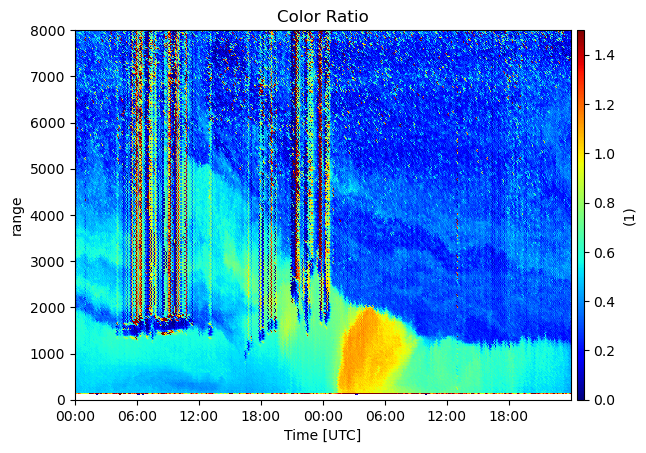

In [12]:
# Plotting Color Ratio
display = act.plotting.TimeSeriesDisplay(bnf_hsrl_spec_features)
display.plot(
    'color_ratio',
    y_rng=[0, 8000],
    cmap='jet',
    vmin=0,
    vmax=1.5,
    set_title="Color Ratio"
)
display.axes[0].set_ylim(0, 8000)
plt.show()

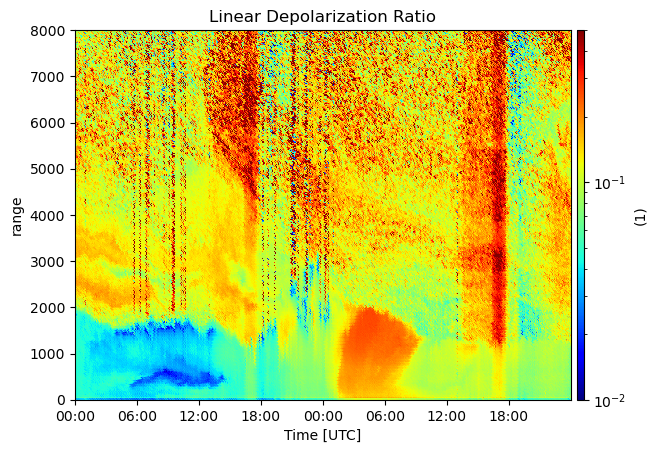

In [13]:
# Plotting Linear Depolarization Ratio
display = act.plotting.TimeSeriesDisplay(bnf_hsrl_spec_features)
display.plot(
    'linear_depol',
    y_rng=[0, 8000],
    cmap='jet',
    norm=colors.LogNorm(vmin=0.01, vmax=0.5),
    set_title='Linear Depolarization Ratio'
)
display.axes[0].set_ylim(0, 8000)
plt.show()

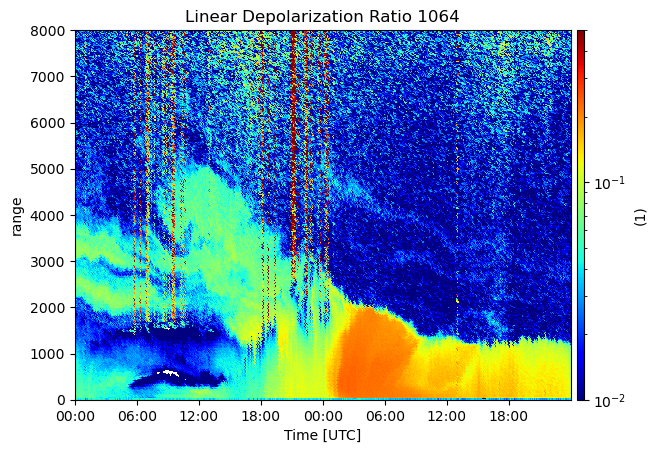

In [14]:
# Plotting Linear Depolarization Ratio 1064
display = act.plotting.TimeSeriesDisplay(bnf_hsrl_spec_features)
display.plot(
    'linear_depol_1064',
    y_rng=[0, 8000],
    cmap='jet',
    norm=colors.LogNorm(vmin=0.01, vmax=0.5),
    set_title='Linear Depolarization Ratio 1064'
)
display.axes[0].set_ylim(0, 8000)
plt.show()

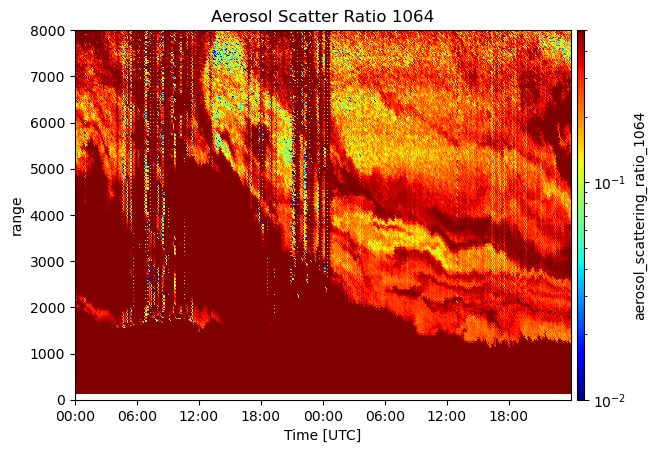

In [15]:
# Plotting Aerosol Scattering Ratio 1064
display = act.plotting.TimeSeriesDisplay(bnf_hsrl_spec_features)
display.plot(
    'aerosol_scattering_ratio_1064',
    y_rng=[0, 8000],
    cmap='jet',
    norm=colors.LogNorm(vmin=0.01, vmax=0.5),
    set_title='Aerosol Scatter Ratio 1064'
)
display.axes[0].set_ylim(0, 8000)
plt.show()

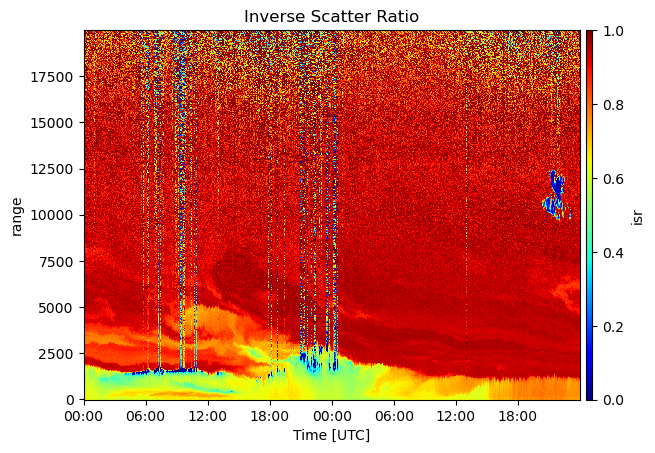

In [19]:
# Plotting Inverse Scatter Ratio
display = act.plotting.TimeSeriesDisplay(bnf_hsrl_spec_features)
display.plot(
    'isr',
    cmap='jet',
    vmin=0,
    vmax=1,
    set_title="Inverse Scatter Ratio"
)
# display.axes[0].set_ylim(0, 8000)
plt.show()

In [49]:
flattened_isr = bnf_hsrl_spec_features['isr'].values.flatten()

In [55]:
bnf_hsrl_spec_features["isr"]

<xarray.DataArray 'isr' (time: 5656, range: 667)> Size: 15MB
dask.array<truediv, shape=(5656, 667), dtype=float32, chunksize=(1, 667), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 45kB 2026-05-13 ... 2026-05-14T23:59:30
  * range    (range) float32 3kB 0.0 30.0 60.0 ... 1.992e+04 1.995e+04 1.998e+04

(array([  5635.,   3614.,   3174.,   2815.,   2686.,   2701.,   2749.,
          2614.,   2668.,   2660.,   2720.,   2894.,   3094.,   3128.,
          3222.,   3547.,   3770.,   4019.,   4414.,   4808.,   5452.,
          6488.,   7714.,   9514.,  11303.,  13410.,  18200.,  24618.,
         31162.,  35529.,  35284.,  44494.,  45881.,  40632.,  33400.,
         38229.,  46011.,  51588.,  66721.,  62908.,  64037.,  86103.,
        119993., 154800., 212690., 313863., 530295., 591278., 306692.,
        150088.]),
 array([6.96124118e-08, 2.00000666e-02, 4.00000624e-02, 6.00000583e-02,
        8.00000578e-02, 1.00000054e-01, 1.20000049e-01, 1.40000045e-01,
        1.60000041e-01, 1.80000037e-01, 2.00000033e-01, 2.20000029e-01,
        2.40000024e-01, 2.60000020e-01, 2.80000031e-01, 3.00000012e-01,
        3.20000023e-01, 3.40000004e-01, 3.60000014e-01, 3.79999995e-01,
        4.00000006e-01, 4.19999987e-01, 4.39999998e-01, 4.59999979e-01,
        4.79999989e-01, 4.99999970e-01, 5.19999981e-

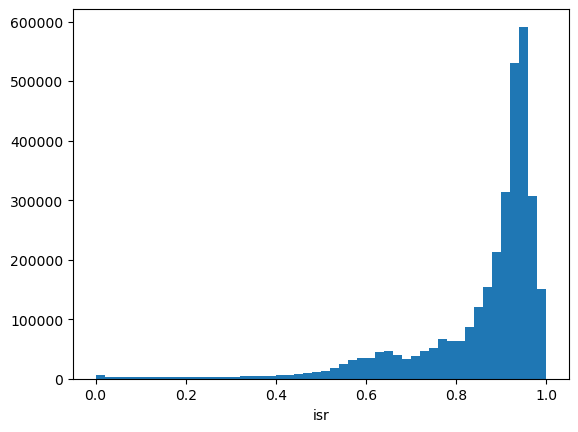

In [70]:
#plotting 0-1 Inverse Scatter Ratio

min_val, max_val = 0, 1

# Filter the DataArray
# Only values between 0 and 1 (exclusive) remain; others become NaN
da = bnf_hsrl_spec_features["isr"]
filtered_da = da.where((da > min_val) & (da < max_val))

filtered_da.plot.hist(bins=50)

(array([107183., 173580., 212172., 228672., 317254., 328716., 288825.,
        222490., 158869., 116521.,  89959.,  76726.,  61538.,  48099.,
         40157.,  34488.,  29987.,  26482.,  23207.,  20663.,  19212.,
         18887.,  14665.,  12663.,  11259.,  10277.,   9498.,   8576.,
          7959.,   7508.,   6742.,   6332.,   5927.,   5578.,   5128.,
          4896.,   4562.,   4299.,   4036.,   3879.,   3641.,   3348.,
          3272.,   3156.,   3014.,   2867.,   2657.,   2579.,   2571.,
          2372.]),
 array([7.18568671e-08, 2.00000666e-02, 4.00000624e-02, 6.00000583e-02,
        8.00000504e-02, 1.00000046e-01, 1.20000042e-01, 1.40000030e-01,
        1.60000026e-01, 1.80000022e-01, 2.00000018e-01, 2.20000014e-01,
        2.40000010e-01, 2.60000020e-01, 2.80000001e-01, 2.99999982e-01,
        3.19999993e-01, 3.39999974e-01, 3.59999985e-01, 3.79999965e-01,
        3.99999976e-01, 4.19999957e-01, 4.39999968e-01, 4.59999949e-01,
        4.79999959e-01, 4.99999940e-01, 5.19999921e-

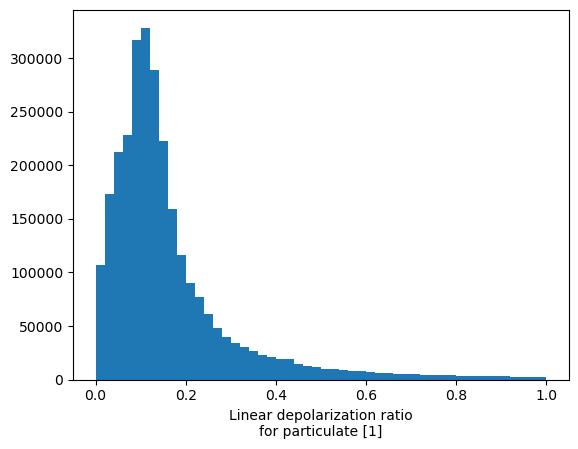

In [69]:
# plotting Linear Depolarization Ratio
min_val, max_val = 0, 1

# Filter the DataArray
# Only values between 0 and 1 (exclusive) remain; others become NaN
da = bnf_hsrl_spec_features["linear_depol"]
filtered_da = da.where((da > min_val) & (da < max_val))

filtered_da.plot.hist(bins=50)

(array([ 66546.,  58216.,  56907.,  58274.,  61614.,  65452.,  71064.,
         77391.,  83549.,  90622.,  97415., 104021., 108585., 111610.,
        111103., 106322.,  97944.,  87091.,  75894.,  65381.,  57660.,
         52425.,  51656.,  52908.,  53767.,  56455.,  60391.,  63047.,
         57367.,  45585.,  36498.,  32495.,  32548.,  31200.,  26145.,
         21604.,  18430.,  16926.,  15498.,  14442.,  13703.,  12484.,
         11635.,  10779.,  10018.,   9762.,   9813.,   9544.,   9840.,
         10341.]),
 array([2.86937734e-07, 2.00002566e-02, 4.00002263e-02, 6.00001998e-02,
        8.00001696e-02, 1.00000136e-01, 1.20000109e-01, 1.40000075e-01,
        1.60000056e-01, 1.80000022e-01, 1.99999988e-01, 2.19999954e-01,
        2.39999935e-01, 2.59999901e-01, 2.79999882e-01, 2.99999833e-01,
        3.19999814e-01, 3.39999795e-01, 3.59999746e-01, 3.79999727e-01,
        3.99999708e-01, 4.19999659e-01, 4.39999640e-01, 4.59999621e-01,
        4.79999572e-01, 4.99999553e-01, 5.19999504e-

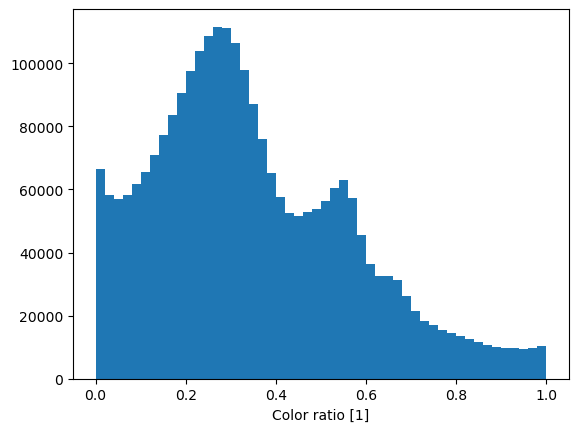

In [71]:
# Plotting color ratio

min_val, max_val = 0, 1

# Filter the DataArray
# Only values between 0 and 1 (exclusive) remain; others become NaN
da = bnf_hsrl_spec_features["color_ratio"]
filtered_da = da.where((da > min_val) & (da < max_val))
filtered_da.plot.hist(bins=50)

### Setup for trying Clustering
We are flattening the features we want for clustering to create 1D Arrays and removing NaN values

In [10]:
cluster_features = ["linear_depol", "color_ratio", "isr"]
hslr_cluster_ds = bnf_hsrl_spec_features[cluster_features]

In [11]:
flattened_linear_depol = hslr_cluster_ds["linear_depol"].values.flatten()
flattened_color_ratio = hslr_cluster_ds["color_ratio"].values.flatten()
flattened_inverse_scatter_ratio  = hslr_cluster_ds["isr"].values.flatten()

In [12]:
flattened_linear_depol.shape

(3772552,)

In [13]:
flattened_color_ratio.shape

(3772552,)

In [14]:
flattened_inverse_scatter_ratio.shape

(3772552,)

In [15]:
# Stack and transpose to (n_samples, n_features)
hsrl_arrays = np.array([flattened_linear_depol, flattened_color_ratio, flattened_inverse_scatter_ratio]).T
clean_hsrl_arrays = hsrl_arrays[~np.isnan(hsrl_arrays).any(axis=1)]

In [16]:
hsrl_arrays.shape

(3772552, 3)

In [17]:
clean_hsrl_arrays.shape

(2427670, 3)

In [18]:
scaler = StandardScaler()

In [19]:
X_scaled = scaler.fit_transform(clean_hsrl_arrays)